# Agent的基本使用

## 1、Agent中模型的传入方式

### 1.1 传入字符串

In [2]:
from dotenv import load_dotenv
from langchain.agents import create_agent

load_dotenv(override=True)

agent = create_agent(
    model= "deepseek:deepseek-v4-flash"   # 调用的是ChatDeepSeek()
)

print(type(agent))

<class 'langgraph.graph.state.CompiledStateGraph'>


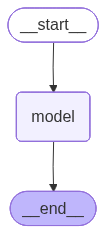

In [3]:
from IPython.display import Image, display
display(Image(agent.get_graph().draw_mermaid_png()))

### 1.2 传入模型实例

In [5]:
import os
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
from langchain.agents import create_agent

load_dotenv(override=True)

# model = init_chat_model(
#     model="deepseek:deepseek-v4-flash",  # 调用的是ChatDeepSeek()
# )

model = init_chat_model(
    model="gpt-5.4-mini",
    model_provider="openai",
    api_key=os.getenv("CLOSEAI_API_KEY"),
    base_url=os.getenv("CLOSEAI_BASE_URL")
)


agent = create_agent(
    model=model
)

print(type(agent))

<class 'langgraph.graph.state.CompiledStateGraph'>


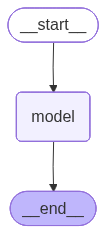

In [6]:
from IPython.display import Image, display
display(Image(agent.get_graph().draw_mermaid_png()))

## 2、如何调用Agent

举例1：

In [8]:
from langchain.agents import create_agent
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
import os
load_dotenv(override=True)
from rich import print as rprint

# 以init_chat_model为例
model = init_chat_model(
    model="gpt-5.4-mini",
    model_provider="openai",
    api_key=os.getenv("CLOSEAI_API_KEY"),
    base_url=os.getenv("CLOSEAI_BASE_URL")
)



agent = create_agent(
    model=model
)

# 调用
# response= agent.invoke({
#     "messages":[
#         {"role":"user","content":"你好"}
#     ]
# })

response= agent.invoke({
    "messages":[
        "你好"
    ]
})

rprint(response)

{
    'messages': [
        HumanMessage(
            content='你好',
            additional_kwargs={},
            response_metadata={},
            id='e5dcab21-9566-47df-b5ac-bad5ea7e73b9'
        ),
        AIMessage(
            content='你好！有什么我可以帮你的吗？',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 13,
                    'prompt_tokens': 7,
                    'total_tokens': 20,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': 0,
                        'audio_tokens': 0,
                        'reasoning_tokens': 0,
                        'rejected_prediction_tokens': 0
                    },
                    'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0},
                    'latency_checkpoint': {
                        'engine_tbt_ms': 3,
                        'engine_ttft_ms': 46,
                        'engine_ttlt_ms': 87,
                        'pre_inference_ms': 110,
                        'service_tbt_ms': 3,
                        'service_ttft_ms': 711,
                        'service_ttlt_ms': 746,
                        'total_duration_ms': 646,
                        'user_visible_ttft_ms': 602
                    }
                },
                'model_provider': 'openai',
                'model_name': 'gpt-5.4-mini-2026-03-17',
                'system_fingerprint': None,
                'id': 'chatcmpl-Dmg6LGthErnN1o26AwVfrrRV39dJe',
                'service_tier': 'default',
                'finish_reason': 'stop',
                'logprobs': None
            },
            id='lc_run--019e8db5-a2e4-7d70-b7c3-a3fe9f0e13bd-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 7,
                'output_tokens': 13,
                'total_tokens': 20,
                'input_token_details': {'audio': 0, 'cache_read': 0},
                'output_token_details': {'audio': 0, 'reasoning': 0}
            }
        )
    ]
}

举例2：

In [9]:
from langchain.agents import create_agent
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
import os
load_dotenv(override=True)
from rich import print as rprint

# 以init_chat_model为例
model = init_chat_model(
    model="gpt-5.4-mini",
    model_provider="openai",
    api_key=os.getenv("CLOSEAI_API_KEY"),
    base_url=os.getenv("CLOSEAI_BASE_URL")
)



agent = create_agent(
    model=model
)

# 调用
response= agent.invoke({
    "messages":[
        {"role":"system","content":"你是一个精通数学的老师，擅长以通俗易懂的方式讲解数学问题"},
        {"role":"user","content":"100 + 20 * 3 = ？"}
    ]
})


rprint(response)

{
    'messages': [
        SystemMessage(
            content='你是一个精通数学的老师，擅长以通俗易懂的方式讲解数学问题',
            additional_kwargs={},
            response_metadata={},
            id='7f0d8a15-a18e-4ee9-83f6-f60e012f7006'
        ),
        HumanMessage(
            content='100 + 20 * 3 = ？',
            additional_kwargs={},
            response_metadata={},
            id='2339bb7a-f228-4333-bc7c-53367389e790'
        ),
        AIMessage(
            content='先算乘法：\n\n- \\(20 \\times 3 = 60\\)\n\n再算加法：\n\n- \\(100 + 60 = 160\\)\n\n所以答案是 
**160**。',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 44,
                    'prompt_tokens': 43,
                    'total_tokens': 87,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': 0,
                        'audio_tokens': 0,
                        'reasoning_tokens': 0,
                        'rejected_prediction_tokens': 0
                    },
                    'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0},
                    'latency_checkpoint': {
                        'engine_tbt_ms': 4,
                        'engine_ttft_ms': 33,
                        'engine_ttlt_ms': 231,
                        'pre_inference_ms': 76,
                        'service_tbt_ms': 5,
                        'service_ttft_ms': 292,
                        'service_ttlt_ms': 482,
                        'total_duration_ms': 420,
                        'user_visible_ttft_ms': 215
                    }
                },
                'model_provider': 'openai',
                'model_name': 'gpt-5.4-mini-2026-03-17',
                'system_fingerprint': None,
                'id': 'chatcmpl-Dmg7y7OFSvrnW0HMOc31Luk0j7QaT',
                'service_tier': 'default',
                'finish_reason': 'stop',
                'logprobs': None
            },
            id='lc_run--019e8db7-2d24-73d3-a7dd-3c336762b6f4-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 43,
                'output_tokens': 44,
                'total_tokens': 87,
                'input_token_details': {'audio': 0, 'cache_read': 0},
                'output_token_details': {'audio': 0, 'reasoning': 0}
            }
        )
    ]
}

## 3、如何绑定工具，并调用工具

### 举例1：绑定一个自定义的工具

In [10]:

from langchain_core.tools import tool
from langchain.agents import create_agent
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
import os
load_dotenv(override=True)
from rich import print as rprint

# 以init_chat_model为例
model = init_chat_model(
    model="gpt-5.4-mini",
    model_provider="openai",
    api_key=os.getenv("CLOSEAI_API_KEY"),
    base_url=os.getenv("CLOSEAI_BASE_URL")
)

# 定义一个工具
@tool(parse_docstring=True)
def get_weather(city : str):
    """
    查询天气的工具

    Args:
        city : 具体的城市
    """
    return f"{city}天气晴朗，温度是15℃"


agent = create_agent(
    model = model,
    tools = [get_weather]
)


response = agent.invoke({
    "messages" : [
        {"role":"system","content":"你是一个查询天气的助手，根据用户的提问查询天气。如果问题跟天气无关，你可以说：我不清楚这个问题的答案"},
        {"role":"user","content":"北京的天气如何？"}
    ]
})

rprint(response)

{
    'messages': [
        SystemMessage(
            content='你是一个查询天气的助手，根据用户的提问查询天气。如果问题跟天气无关，你可以说：我不清楚这个问题
的答案',
            additional_kwargs={},
            response_metadata={},
            id='f676e465-aca9-469d-82f4-b668f36acd78'
        ),
        HumanMessage(
            content='北京的天气如何？',
            additional_kwargs={},
            response_metadata={},
            id='719e990a-81d8-429f-a39f-1a6827a1ba33'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 18,
                    'prompt_tokens': 170,
                    'total_tokens': 188,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': 0,
                        'audio_tokens': 0,
                        'reasoning_tokens': 0,
                        'rejected_prediction_tokens': 0
                    },
                    'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0},
                    'latency_checkpoint': {
                        'engine_tbt_ms': 11,
                        'engine_ttft_ms': 135,
                        'engine_ttlt_ms': 340,
                        'pre_inference_ms': 94,
                        'service_tbt_ms': 12,
                        'service_ttft_ms': 818,
                        'service_ttlt_ms': 1017,
                        'total_duration_ms': 932,
                        'user_visible_ttft_ms': 724
                    }
                },
                'model_provider': 'openai',
                'model_name': 'gpt-5.4-mini-2026-03-17',
                'system_fingerprint': None,
                'id': 'chatcmpl-DmgQANJLGFzARwjtPmTPQPs1lC4Fm',
                'service_tier': 'default',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--019e8dc8-63c2-7a22-b87d-b192ffe95044-0',
            tool_calls=[
                {
                    'name': 'get_weather',
                    'args': {'city': '北京'},
                    'id': 'call_DPkqzBdPpUHfSfEvr3NvJhka',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 170,
                'output_tokens': 18,
                'total_tokens': 188,
                'input_token_details': {'audio': 0, 'cache_read': 0},
                'output_token_details': {'audio': 0, 'reasoning': 0}
            }
        ),
        ToolMessage(
            content='北京天气晴朗，温度是15℃',
            name='get_weather',
            id='452810b7-c3e4-4ef0-a535-6a753c6f454c',
            tool_call_id='call_DPkqzBdPpUHfSfEvr3NvJhka'
        ),
        AIMessage(
            content='北京天气晴朗，温度是 15℃】【。',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 16,
                    'prompt_tokens': 208,
                    'total_tokens': 224,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': 0,
                        'audio_tokens': 0,
                        'reasoning_tokens': 0,
                        'rejected_prediction_tokens': 0
                    },
                    'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0},
                    'latency_checkpoint': {
                        'engine_tbt_ms': 5,
                        'engine_ttft_ms': 49,
                        'engine_ttlt_ms': 129,
                        'pre_inference_ms': 98,
                        'service_tbt_ms': 5,
                        'service_ttft_ms': 728,
                        'service_ttlt_ms': 805,
                        'total_duration_ms': 717,
                        'user_visible_ttft_ms': 630
                    }
            

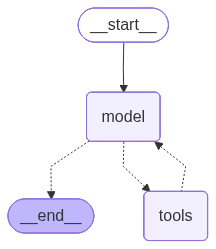

In [11]:
from IPython.display import Image, display

display(Image(agent.get_graph().draw_mermaid_png()))

### 举例2：调用langchain内置的工具

In [12]:

from langchain_tavily import TavilySearch
from langchain_core.tools import tool
from langchain.agents import create_agent
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
import os
load_dotenv(override=True)
from rich import print as rprint

# 以init_chat_model为例
model = init_chat_model(
    model="gpt-5.4-mini",
    model_provider="openai",
    api_key=os.getenv("CLOSEAI_API_KEY"),
    base_url=os.getenv("CLOSEAI_BASE_URL")
)

# 使用内置的工具
web_search = TavilySearch(
    max_results=2,
    tavily_api_key=os.getenv("TAVILY_API_KEY"),
)


agent = create_agent(
    model = model,
    tools = [web_search]
)


response = agent.invoke({
    "messages" : [
        {"role": "user", "content": "请帮我查询2024年诺贝尔物理学奖得主是谁？"}
    ]
})

rprint(response)

{
    'messages': [
        HumanMessage(
            content='请帮我查询2024年诺贝尔物理学奖得主是谁？',
            additional_kwargs={},
            response_metadata={},
            id='c4bbfcc2-562a-46eb-94d9-f1888e2a9f93'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 51,
                    'prompt_tokens': 1286,
                    'total_tokens': 1337,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': 0,
                        'audio_tokens': 0,
                        'reasoning_tokens': 0,
                        'rejected_prediction_tokens': 0
                    },
                    'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0},
                    'latency_checkpoint': {
                        'engine_tbt_ms': 7,
                        'engine_ttft_ms': 64,
                        'engine_ttlt_ms': 425,
                        'pre_inference_ms': 109,
                        'service_tbt_ms': 7,
                        'service_ttft_ms': 435,
                        'service_ttlt_ms': 788,
                        'total_duration_ms': 694,
                        'user_visible_ttft_ms': 325
                    }
                },
                'model_provider': 'openai',
                'model_name': 'gpt-5.4-mini-2026-03-17',
                'system_fingerprint': None,
                'id': 'chatcmpl-DmgWsXPKKFpWd2cwoLdH01fao7ZkG',
                'service_tier': 'default',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--019e8dce-ba49-71b1-84af-05e9c46e9ffd-0',
            tool_calls=[
                {
                    'name': 'tavily_search',
                    'args': {
                        'query': '2024 Nobel Prize in Physics laureates official Nobel Prize',
                        'include_domains': ['nobelprize.org'],
                        'search_depth': 'advanced',
                        'topic': 'general'
                    },
                    'id': 'call_MVJNZj0NS0ZwUCZv7QbBi6tH',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 1286,
                'output_tokens': 51,
                'total_tokens': 1337,
                'input_token_details': {'audio': 0, 'cache_read': 0},
                'output_token_details': {'audio': 0, 'reasoning': 0}
            }
        ),
        ToolMessage(
            content='{"query": "2024 Nobel Prize in Physics laureates official Nobel Prize", "follow_up_questions":
null, "answer": null, "images": [], "results": [{"url": 
"https://www.nobelprize.org/prizes/physics/2024/press-release", "title": "Press release: The Nobel Prize in Physics
2024 - NobelPrize.org", "content": "Prize amount: 11 million Swedish kronor, to be shared equally between the 
laureates. Further information: www.kva.se and www.nobelprize.org Press contact: Eva Nevelius, Press Secretary, +46
70 878 67 63, (/cdn-cgi/l/email-protection)  \\nExperts: Olle Eriksson, +46 18 471 36 25, 
(/cdn-cgi/l/email-protection) and Anders Irbäck, +46 46 222 34 93, (/cdn-cgi/l/email-protection), members of the 
Nobel Committee for Physics.\\n\\nThe Royal Swedish Academy of Sciences, founded in 1739, is an independent 
organisation whose overall objective is to promote the sciences and strengthen their influence in society. The 
Academy takes special responsibility for the natural sciences and mathematics, but endeavours to promote the 
exchange of ideas between various disciplines. [...] # Nobel Prize\\n\\n### Enhanced Page Navigation\\n\\n## Nobel 
Prize in Physics 2024\\n\\n## Share this\\n\\n# Press release\\n\\nEnglish  \\nEnglish (pdf)  \\nSwedish  
\\nSwedish (pdf)\\n\\nLogo\\n\\n8 Octobe

### 举例3：绑定多个工具，并调用

In [13]:
from langchain.agents import create_agent
from langchain.tools import tool
from dotenv import load_dotenv
from rich import print as rprint

load_dotenv(override=True)

@tool(parse_docstring=True)
def get_weather(city: str):
    """
    天气查询工具

    Args:
        city: 城市名称
    """
    return f"{city}今天天气挺好"

@tool(parse_docstring=True)
def get_news():
    """
    新闻查询工具
    """
    return "近期，受全球储蓄芯片短缺等多重因素影响，多地回收商称废旧手机回收市场迎来“火热潮”，回收价格普遍上涨，旧手机成“香饽饽”。"

agent = create_agent(
    model,
    tools=[get_weather, get_news]
)
response = agent.invoke({
    "messages": ["你好，杭州今天的天气如何？今天有哪些新闻？"]
})

rprint(response)


{
    'messages': [
        HumanMessage(
            content='你好，杭州今天的天气如何？今天有哪些新闻？',
            additional_kwargs={},
            response_metadata={},
            id='a236a813-0beb-4891-95ea-3dfcf208de08'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 46,
                    'prompt_tokens': 152,
                    'total_tokens': 198,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': 0,
                        'audio_tokens': 0,
                        'reasoning_tokens': 0,
                        'rejected_prediction_tokens': 0
                    },
                    'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0},
                    'latency_checkpoint': {
                        'engine_tbt_ms': 2,
                        'engine_ttft_ms': 31,
                        'engine_ttlt_ms': 142,
                        'pre_inference_ms': 81,
                        'service_tbt_ms': 2,
                        'service_ttft_ms': 280,
                        'service_ttlt_ms': 383,
                        'total_duration_ms': 310,
                        'user_visible_ttft_ms': 198
                    }
                },
                'model_provider': 'openai',
                'model_name': 'gpt-5.4-mini-2026-03-17',
                'system_fingerprint': None,
                'id': 'chatcmpl-DmgZmTLzW3C6wFzfgGIUEBxP9uVtu',
                'service_tier': 'default',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--019e8dd1-7c17-7d50-aa74-6513f05acce9-0',
            tool_calls=[
                {
                    'name': 'get_weather',
                    'args': {'city': '杭州'},
                    'id': 'call_MCnh8KphvHx4PHhMfExPrUah',
                    'type': 'tool_call'
                },
                {'name': 'get_news', 'args': {}, 'id': 'call_3lHndtx89QwCrip6KReupwgF', 'type': 'tool_call'}
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 152,
                'output_tokens': 46,
                'total_tokens': 198,
                'input_token_details': {'audio': 0, 'cache_read': 0},
                'output_token_details': {'audio': 0, 'reasoning': 0}
            }
        ),
        ToolMessage(
            content='杭州今天天气挺好',
            name='get_weather',
            id='5ba5d6fa-3866-40d1-aeba-a7399ce47250',
            tool_call_id='call_MCnh8KphvHx4PHhMfExPrUah'
        ),
        ToolMessage(
            content='近期，受全球储蓄芯片短缺等多重因素影响，多地回收商称废旧手机回收市场迎来“火热潮”，回收价格普遍
上涨，旧手机成“香饽饽”。',
            name='get_news',
            id='982116b3-ba2f-40aa-8b10-461825aa059a',
            tool_call_id='call_3lHndtx89QwCrip6KReupwgF'
        ),
        AIMessage(
            content='杭州今天天气挺好。\n\n今天的新闻有：\n- 
近期受全球储蓄芯片短缺等多重因素影响，多地回收商称废旧手机回收市场迎来“火热潮”，回收价格普遍上涨，旧手机成了“香饽饽
”。\n\n如果你愿意，我也可以继续帮你整理成“天气 + 新闻摘要”的简版。',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 91,
                    'prompt_tokens': 272,
                    'total_tokens': 363,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': 0,
                        'audio_tokens': 0,
                        'reasoning_tokens': 0,
                        'rejected_prediction_tokens': 0
                    },
                    'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0},
                    'latency_checkpoint': {
                        'engine_tbt_ms': 3,
                        'engine_ttft_ms': 24,
                        'engine_ttlt_ms': 299,
                        'pre_inference_ms': 103,
                        'ser

## 4、重试机制

举例

In [14]:
from langchain.agents import create_agent
from langchain.tools import tool
from langchain.messages import SystemMessage, HumanMessage
from dotenv import load_dotenv
from rich import print as rprint

load_dotenv(override=True)

flag = 0

@tool
def get_weather(city: str):
    """
    天气查询工具

    Args:
        city: 城市名称
    """
    global flag
    flag += 1

    if flag < 3:
        # raise Exception("暂时无法访问")
        return "TEMP_UNAVAILABLE: 天气服务暂时不可用，请稍后重试"

    return f"{city}今天天气挺好"


messages = [
    SystemMessage("""
    你是一个天气助手。
    当工具返回以 'TEMP_UNAVAILABLE:' 开头的结果时，
    说明是临时故障，不要立即放弃；
    你应再次调用同一个工具，最多重试 3 次。
    如果 3 次后仍失败，再向用户说明服务暂时不可用。
    """),
    HumanMessage("你好，杭州今天的天气如何？")
]
agent = create_agent(model, tools=[get_weather])
response = agent.invoke({"messages": messages})

rprint(response)

# for msg in response["messages"]:
#     msg.pretty_print()

{
    'messages': [
        SystemMessage(
            content="\n    你是一个天气助手。\n    当工具返回以 'TEMP_UNAVAILABLE:' 开头的结果时，\n    
说明是临时故障，不要立即放弃；\n    你应再次调用同一个工具，最多重试 3 次。\n    如果 3 
次后仍失败，再向用户说明服务暂时不可用。\n    ",
            additional_kwargs={},
            response_metadata={},
            id='dd64f275-9056-4b9f-bde3-6b3d7164e7aa'
        ),
        HumanMessage(
            content='你好，杭州今天的天气如何？',
            additional_kwargs={},
            response_metadata={},
            id='90100dcc-884c-45bc-baba-ddb23855699f'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 18,
                    'prompt_tokens': 217,
                    'total_tokens': 235,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': 0,
                        'audio_tokens': 0,
                        'reasoning_tokens': 0,
                        'rejected_prediction_tokens': 0
                    },
                    'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0},
                    'latency_checkpoint': {
                        'engine_tbt_ms': 4,
                        'engine_ttft_ms': 39,
                        'engine_ttlt_ms': 104,
                        'pre_inference_ms': 77,
                        'service_tbt_ms': 4,
                        'service_ttft_ms': 285,
                        'service_ttlt_ms': 341,
                        'total_duration_ms': 273,
                        'user_visible_ttft_ms': 207
                    }
                },
                'model_provider': 'openai',
                'model_name': 'gpt-5.4-mini-2026-03-17',
                'system_fingerprint': None,
                'id': 'chatcmpl-Dmh1KhDYQbeLrZLagGq5GRJzUgKNU',
                'service_tier': 'default',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--019e8deb-8a24-7a11-ada2-e40ae948107c-0',
            tool_calls=[
                {
                    'name': 'get_weather',
                    'args': {'city': '杭州'},
                    'id': 'call_TqwVPrvCG1b9W3Tjtvr75st7',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 217,
                'output_tokens': 18,
                'total_tokens': 235,
                'input_token_details': {'audio': 0, 'cache_read': 0},
                'output_token_details': {'audio': 0, 'reasoning': 0}
            }
        ),
        ToolMessage(
            content='TEMP_UNAVAILABLE: 天气服务暂时不可用，请稍后重试',
            name='get_weather',
            id='5212e00e-4977-4d37-9650-561fccd6879f',
            tool_call_id='call_TqwVPrvCG1b9W3Tjtvr75st7'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 18,
                    'prompt_tokens': 261,
                    'total_tokens': 279,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': 0,
                        'audio_tokens': 0,
                        'reasoning_tokens': 0,
                        'rejected_prediction_tokens': 0
                    },
                    'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0},
                    'latency_checkpoint': {
                        'engine_tbt_ms': 4,
                        'engine_ttft_ms': 42,
                        'engine_ttlt_ms': 111,
                        'pre_inference_ms': 88,
                        'service_tbt_ms': 3,
                        'service_ttft_ms': 315,
                        'service_ttlt_ms': 365,
                        'total_duration_m